# H3 — LDI Post > Mid > Pre

Simple paired t-tests (one-sided):
- Post > Mid
- Mid > Pre
- Post > Pre

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

sns.set(style='whitegrid', context='talk')

df = pd.read_csv(r'C:\Users\Satyajit\Desktop\BRSM EXP\DATA\compiled_preprocessed.csv')
df['boundary_position'] = pd.Categorical(df['boundary_position'], categories=['Pre', 'Mid', 'Post'], ordered=True)

In [2]:
def p_resp(data, trial_type, response, boundary=None):
    x = data[data['trial_type'] == trial_type]
    if boundary is not None:
        x = x[x['boundary_position'] == boundary]
    if x.empty:
        return np.nan
    return (x['user_response'] == response).mean()

rows = []
for (pid, cond), sub in df.groupby(['participant_id', 'condition']):
    foil_sim = p_resp(sub, 'Foil', 'Lure')
    rows.append({
        'id': str(pid),
        'LDI_pre': p_resp(sub, 'Lure', 'Lure', 'Pre') - foil_sim,
        'LDI_mid': p_resp(sub, 'Lure', 'Lure', 'Mid') - foil_sim,
        'LDI_post': p_resp(sub, 'Lure', 'Lure', 'Post') - foil_sim
    })

wide = pd.DataFrame(rows).dropna()
print('Complete participants:', len(wide))
display(wide[['LDI_pre', 'LDI_mid', 'LDI_post']].mean().to_frame('mean').T)

Complete participants: 160


,LDI_pre,LDI_mid,LDI_post
mean,0.323125,0.329688,0.31875


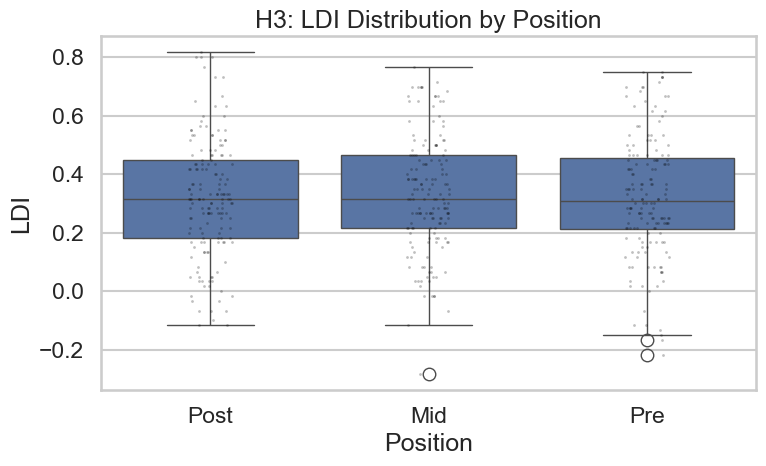

In [3]:
# Visualization: participant-level LDI distributions by position
long = wide.melt(value_vars=['LDI_pre', 'LDI_mid', 'LDI_post'], var_name='position', value_name='LDI')
long['position'] = long['position'].str.replace('LDI_', '').str.capitalize()

plt.figure(figsize=(8, 5))
sns.boxplot(data=long, x='position', y='LDI', order=['Post', 'Mid', 'Pre'])
sns.stripplot(data=long, x='position', y='LDI', order=['Post', 'Mid', 'Pre'], color='black', alpha=0.25, size=2)
plt.title('H3: LDI Distribution by Position')
plt.xlabel('Position')
plt.ylabel('LDI')
plt.tight_layout()
plt.show()

In [4]:
tests = []
for a, b in [('LDI_post', 'LDI_mid'), ('LDI_mid', 'LDI_pre'), ('LDI_post', 'LDI_pre')]:
    test = ttest_rel(wide[a], wide[b], alternative='greater')
    tests.append({
        'comparison': f'{a} > {b}',
        'mean_diff': (wide[a] - wide[b]).mean(),
        't_stat': test.statistic,
        'p_value': test.pvalue,
        'supported (p<.05)': test.pvalue < 0.05
    })

result_df = pd.DataFrame(tests)
display(result_df)

,comparison,mean_diff,t_stat,p_value,supported (p<.05)
0,LDI_post > LDI_mid,-0.010937,-0.875181,0.808602,False
1,LDI_mid > LDI_pre,0.006562,0.572256,0.283978,False
2,LDI_post > LDI_pre,-0.004375,-0.359298,0.640075,False


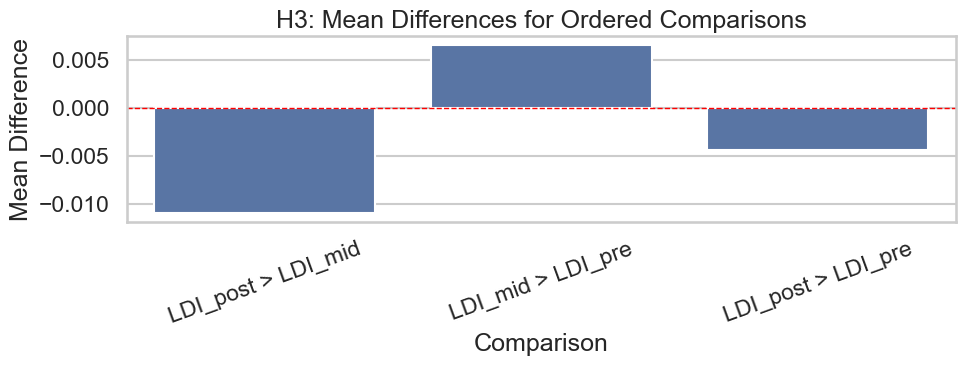

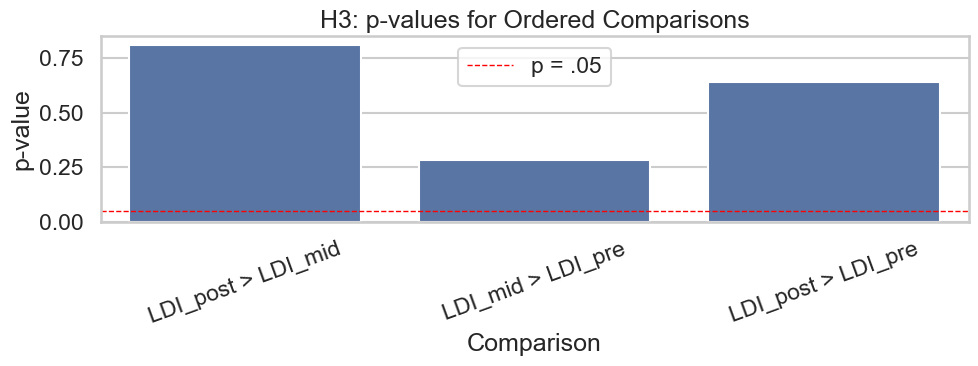

In [5]:
# Visualization: mean differences and p-values from paired tests
plot_df = result_df.copy()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x='comparison', y='mean_diff')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('H3: Mean Differences for Ordered Comparisons')
plt.xlabel('Comparison')
plt.ylabel('Mean Difference')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x='comparison', y='p_value')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p = .05')
plt.title('H3: p-values for Ordered Comparisons')
plt.xlabel('Comparison')
plt.ylabel('p-value')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

task_only: complete participants = 53
item_only: complete participants = 56
both: complete participants = 51


,condition,comparison,mean_diff,t_stat,p_value,p_bonferroni,reject_bonferroni_0.05,p_holm,reject_holm_0.05
0,task_only,LDI_post > LDI_mid,1.698113e-02,7.819552e-01,0.218894,0.656681,False,0.656681,False
1,task_only,LDI_mid > LDI_pre,-1.886792e-02,-9.924423e-01,0.837211,1.000000,False,1.000000,False
2,task_only,LDI_post > LDI_pre,-1.886792e-03,-1.024476e-01,0.540602,1.000000,False,1.000000,False
3,item_only,LDI_post > LDI_mid,-1.607143e-02,-7.689219e-01,0.777385,1.000000,False,1.000000,False
4,item_only,LDI_mid > LDI_pre,1.607143e-02,8.333463e-01,0.204127,0.612381,False,0.612381,False
5,item_only,LDI_post > LDI_pre,7.930164e-18,3.552249e-16,0.500000,1.000000,False,1.000000,False
6,both,LDI_post > LDI_mid,-3.431373e-02,-1.545228e+00,0.935701,1.000000,False,1.000000,False
7,both,LDI_mid > LDI_pre,2.254902e-02,1.061092e+00,0.146873,0.440620,False,0.440620,False
8,both,LDI_post > LDI_pre,-1.176471e-02,-5.214632e-01,0.697827,1.000000,False,1.000000,False


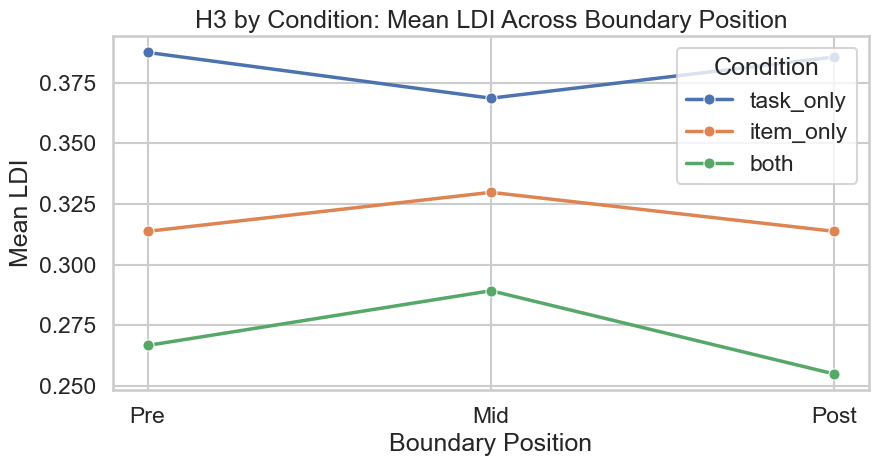

In [6]:
# H3 separately by condition: task_only, item_only, both + graph
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

# Make this cell runnable even if earlier cells were not run.
if 'df' not in globals():
    df = pd.read_csv(r'C:\Users\Satyajit\Desktop\BRSM EXP\DATA\compiled_preprocessed.csv')
    df['boundary_position'] = pd.Categorical(
        df['boundary_position'], categories=['Pre', 'Mid', 'Post'], ordered=True
    )

if 'p_resp' not in globals():
    def p_resp(data, trial_type, response, boundary=None):
        x = data[data['trial_type'] == trial_type]
        if boundary is not None:
            x = x[x['boundary_position'] == boundary]
        if x.empty:
            return np.nan
        return (x['user_response'] == response).mean()

def build_wide_for_condition(data, cond_value):
    rows = []
    subset = data[data['condition'] == cond_value]
    for pid, sub in subset.groupby('participant_id'):
        foil_sim = p_resp(sub, 'Foil', 'Lure')
        rows.append({
            'participant_id': pid,
            'LDI_pre': p_resp(sub, 'Lure', 'Lure', 'Pre') - foil_sim,
            'LDI_mid': p_resp(sub, 'Lure', 'Lure', 'Mid') - foil_sim,
            'LDI_post': p_resp(sub, 'Lure', 'Lure', 'Post') - foil_sim
        })
    return pd.DataFrame(rows).dropna()

# Map your dataset condition labels to standardized names.
condition_map = {}
for cond in sorted(df['condition'].dropna().unique()):
    c = str(cond).lower()
    if ('task' in c) and ('item' not in c):
        condition_map['task_only'] = cond
    elif ('item' in c) and ('task' not in c):
        condition_map['item_only'] = cond
    elif ('both' in c) or (('task' in c) and ('item' in c)):
        condition_map['both'] = cond

missing = [k for k in ['task_only', 'item_only', 'both'] if k not in condition_map]
if missing:
    raise ValueError(
        f"Could not map these conditions: {missing}. Available condition labels: {sorted(df['condition'].dropna().unique())}"
    )

order = ['LDI_post', 'LDI_mid', 'LDI_pre']
pairs = [('LDI_post', 'LDI_mid'), ('LDI_mid', 'LDI_pre'), ('LDI_post', 'LDI_pre')]
all_tests = []
mean_rows = []

for cond_short in ['task_only', 'item_only', 'both']:
    cond_value = condition_map[cond_short]
    wide_cond = build_wide_for_condition(df, cond_value)

    n = len(wide_cond)
    print(f"{cond_short}: complete participants = {n}")

    means = wide_cond[order].mean().reset_index()
    means.columns = ['metric', 'LDI']
    means['position'] = means['metric'].str.replace('LDI_', '').str.capitalize()
    means['condition'] = cond_short
    mean_rows.append(means[['condition', 'position', 'LDI']])

    for a, b in pairs:
        if n < 2:
            t_stat, p_val = np.nan, np.nan
        else:
            res = ttest_rel(wide_cond[a], wide_cond[b], alternative='greater')
            t_stat, p_val = res.statistic, res.pvalue

        all_tests.append({
            'condition': cond_short,
            'comparison': f'{a} > {b}',
            'mean_diff': (wide_cond[a] - wide_cond[b]).mean() if n else np.nan,
            't_stat': t_stat,
            'p_value': p_val
        })

results_by_condition = pd.DataFrame(all_tests)

# Apply multiple-testing corrections within each condition (3 comparisons each).
results_by_condition['p_bonferroni'] = np.nan
results_by_condition['reject_bonferroni_0.05'] = False
results_by_condition['p_holm'] = np.nan
results_by_condition['reject_holm_0.05'] = False

for cond_short in ['task_only', 'item_only', 'both']:
    idx = results_by_condition['condition'] == cond_short
    pvals = results_by_condition.loc[idx, 'p_value'].to_numpy()

    valid_mask = ~np.isnan(pvals)
    if valid_mask.sum() == 0:
        continue

    pvals_valid = pvals[valid_mask]
    reject_bonf, p_bonf, _, _ = multipletests(pvals_valid, alpha=0.05, method='bonferroni')
    reject_holm, p_holm, _, _ = multipletests(pvals_valid, alpha=0.05, method='holm')

    cond_indices = results_by_condition.index[idx]
    valid_indices = cond_indices[valid_mask]
    results_by_condition.loc[valid_indices, 'p_bonferroni'] = p_bonf
    results_by_condition.loc[valid_indices, 'reject_bonferroni_0.05'] = reject_bonf
    results_by_condition.loc[valid_indices, 'p_holm'] = p_holm
    results_by_condition.loc[valid_indices, 'reject_holm_0.05'] = reject_holm

display(results_by_condition)

plot_means = pd.concat(mean_rows, ignore_index=True)
plot_means['position'] = pd.Categorical(plot_means['position'], categories=['Pre', 'Mid', 'Post'], ordered=True)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=plot_means, x='position', y='LDI', hue='condition',
    marker='o', linewidth=2.5, markersize=8
)
plt.title('H3 by Condition: Mean LDI Across Boundary Position')
plt.xlabel('Boundary Position')
plt.ylabel('Mean LDI')
plt.legend(title='Condition')
plt.tight_layout()
plt.show()